<a href="https://colab.research.google.com/github/qu1r0ra/jute-disease-detection/blob/main/notebooks/reproducibility/03_Model_Analysis_Tuning_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning - Model Analysis and Fine-Tuning

In the [previous notebook](./02_Model_Selection_Training_DL.ipynb), we trained baseline DL models and chose a configuration to move forward with. We concluded with a MobileNet V2 pre-trained on ImageNet-1K with a dropout rate of 0.1 as our best model moving forward.

In this notebook, we will analyze the model's performance and fine-tune chosen hyperparameters (not to be confused with fine-tuning for model training) in the hopes of improving its performance.

Specifically, we will:
- Compare the performance of our 256x256 pixel and 512x512 pixel MobileNet V2 models.
- Visualize the training history to inspect for possible overfitting or underfitting.
- Conduct error analysis by exploring latent space embeddings (t-SNE and UMAP) and inspecting the top confident errors.
- Use Grad-CAM to visualize where the model focuses on in various images.

**Notes:**

- Like the [previous notebook](./02_Model_Selection_Training_DL.ipynb), this is expected to be executed in **Google Colab**. What Colab GPU to use is technically up to you, but we recommend sticking to whatever you used in the previous notebook for fair model comparison. In our case, we used an **L4**.
- This time, we chose not to abstract the visualization logic into separate scripts to allow for quick inline revisions.

## Outline

- [Environment Setup](#environment-setup)
- [Part 1: Baseline Analysis](#part-1-baseline-analysis)
  - [1A. Model Performance](#1a-model-performance)
  - [1B. Error Analysis](#1b-error-analysis)
  - [1C. Latent Space Analysis](#1c-latent-space-analysis)
  - [1D. Interpretability](#1d-interpretability)
- [Part 2: Optimizer Fine-Tuning](#part-2-optimizer-fine-tuning)
  - [2A. Model Performance](#2a-model-performance)
  - [2B. Error Analysis](#2b-error-analysis)
  - [2C. Interpretability](#2c-interpretability)
- [Conclusion](#conclusion)
- [References](#references)

## Environment Setup

Let's run the environment setup again. Refer to the [previous notebook](./02_Model_Selection_Training_DL.ipynb) for detailed instructions and remarks.

In [ ]:
!git clone https://github.com/qu1r0ra/jute-disease-detection.git
%cd jute-disease-detection

%pip install uv
!uv pip install --system -e .
!uv sync

> If you encounter `ModuleNotFoundError`, you can simply restart the session and rerun the cell below.

In [1]:
# ruff: noqa: T201
from jute_disease.utils.constants import DEFAULT_SEED
from jute_disease.utils.seed import seed_everything

seed_everything(DEFAULT_SEED)

/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


2026-03-10 10:47:04,483 - jute_disease.utils.seed - INFO - Random seed set to: 42


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

In [ ]:
%cd jute-disease-detection

In [ ]:
from pathlib import Path

# Update DATA_ZIP_PATH to where data.zip is stored relative to the Colab VM filesystem.
# For organization, we stored ours in
# "/content/drive/MyDrive/Colab Notebooks/Jute Leaf Disease/data.zip"
DATA_ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Jute Leaf Disease/data.zip"
DEST_PATH = Path("data/by_class")

if Path(DATA_ZIP_PATH).exists():
    DEST_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Unzipping {DATA_ZIP_PATH} to {DEST_PATH}...")
    !unzip -q -n "$DATA_ZIP_PATH" -d "$DEST_PATH"
    print("Data unzipped.")
else:
    print(
        f"Zip file not found at {DATA_ZIP_PATH}. "
        "Please check the path or upload your data."
    )

In [ ]:
!uv run python src/jute_disease/data/utils.py split

In [ ]:
import shutil

GDRIVE_PATH = Path(DATA_ZIP_PATH).parent
GDRIVE_ARTIFACTS = GDRIVE_PATH / "artifacts"
GDRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)

LOCAL_ARTIFACTS = Path("artifacts")

if not LOCAL_ARTIFACTS.is_symlink():
    if LOCAL_ARTIFACTS.exists():
        shutil.copytree(LOCAL_ARTIFACTS, GDRIVE_ARTIFACTS, dirs_exist_ok=True)
        shutil.rmtree(LOCAL_ARTIFACTS)
    LOCAL_ARTIFACTS.symlink_to(GDRIVE_ARTIFACTS)
    print(f"Symlinked {LOCAL_ARTIFACTS.absolute()} to {GDRIVE_ARTIFACTS}")
else:
    print(f"{LOCAL_ARTIFACTS} is already linked.")

In [ ]:
test_file = LOCAL_ARTIFACTS / "test.txt"
test_file.write_text("Hacking into the mainframe, part 2.")

if (GDRIVE_ARTIFACTS / "test.txt").exists():
    print("Symlink worked.")
else:
    print("Symlink failed :<")

## Part 1: Baseline Analysis

### 1A. Model Performance

#### Impact of a Higher Image Resolution on Model Performance

Let's begin by analyzing how training on a higher image resolution impacts our model's performance. Recall that our models were originally trained on 256x256 pixel images and that we trained 512x512 pixel counterparts for the pre-trained MobileNet V2 with dropout rates 0.0 and 0.1 for comparison.

2026-03-10 10:48:39,752 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-10 10:48:39,764 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


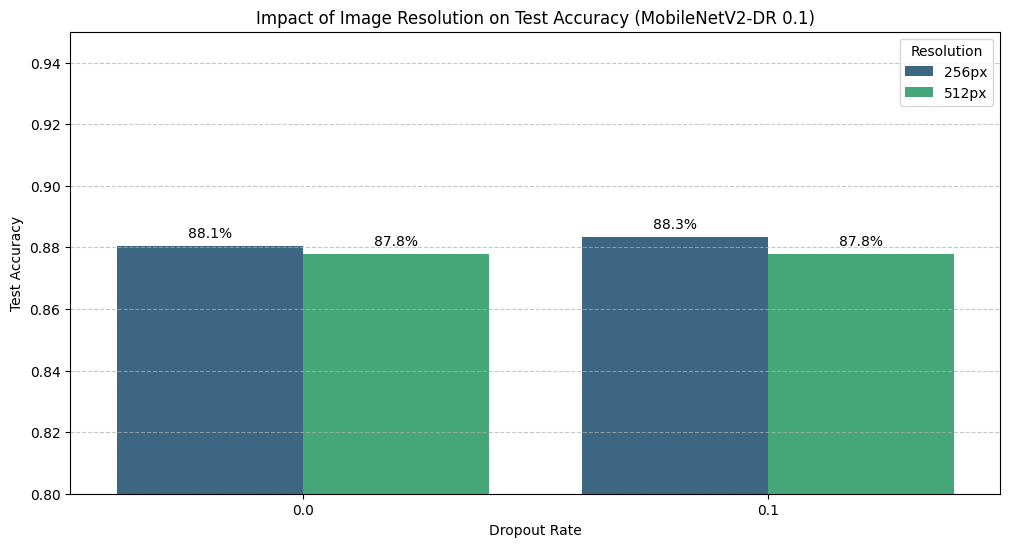

,Experiment,test_acc,test_f1,test_loss
0,mobilenet_v2-l1_imagenet-dr_0.0,0.880556,0.883580,0.320347
1,mobilenet_v2-512px-dr_0.0,0.877778,0.880819,0.362757
2,mobilenet_v2-l1_imagenet-dr_0.1,0.883333,0.886336,0.324702
3,mobilenet_v2-512px-dr_0.1,0.877778,0.881310,0.366990


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from jute_disease.utils import get_logger
from jute_disease.utils.constants import (
    ARTIFACTS_DIR,
    BATCH_SIZE,
    DEFAULT_SEED,
    DPI,
    FIGURES_DL_DIR,
    LOGS_DIR,
    ML_SPLIT_DIR,
    NUM_WORKERS,
)

logger = get_logger("AnalysisNoteBook")

metrics_path = LOGS_DIR / "phase1_transfer_grid" / "aggregated_grid_metrics.csv"
res_512_00 = (
    LOGS_DIR / "resolution_exps" / "mobilenet_v2-512px-dr_0.0" / "summary_metrics.csv"
)
res_512_01 = (
    LOGS_DIR / "resolution_exps" / "mobilenet_v2-512px-dr_0.1" / "summary_metrics.csv"
)

if not metrics_path.exists():
    raise FileNotFoundError(f"Metrics file not found: {metrics_path}")

df_phase1 = pd.read_csv(metrics_path)
extra_results = []
if res_512_00.exists():
    df_512_00 = pd.read_csv(res_512_00)
    extra_results.append(df_512_00)
if res_512_01.exists():
    df_512_01 = pd.read_csv(res_512_01)
    extra_results.append(df_512_01)

if extra_results:
    df = pd.concat([df_phase1] + extra_results, ignore_index=True)
else:
    df = df_phase1

plt.figure(figsize=(12, 6))
comparison_names = [
    "mobilenet_v2-l1_imagenet-dr_0.1",
    "mobilenet_v2-512px-dr_0.1",
    "mobilenet_v2-l1_imagenet-dr_0.0",
    "mobilenet_v2-512px-dr_0.0",
]
comp_df = df[df["Experiment"].isin(comparison_names)].copy()
comp_df["Resolution"] = comp_df["Experiment"].apply(
    lambda x: "512px" if "512px" in x else "256px"
)
comp_df["Dropout Rate"] = comp_df["Experiment"].apply(
    lambda x: 0.1 if "dr_0.1" in x else 0.0
)
comp_df = comp_df.sort_values("Dropout Rate")

ax_bar = sns.barplot(
    data=comp_df,
    x="Dropout Rate",
    y="test_acc",
    hue="Resolution",
    palette="viridis",
)
plt.ylim(0.8, 0.95)
plt.title("Impact of Image Resolution on Test Accuracy (MobileNetV2-DR 0.1)")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for p in ax_bar.patches:
    height = p.get_height()
    if height > 0:
        ax_bar.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points",
        )

FIGURES_DL_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DL_DIR / "resolution_impact.png", bbox_inches="tight", dpi=DPI)
plt.show()

display(
    comp_df[["Experiment", "test_acc", "test_f1", "test_loss"]].reset_index(drop=True)
)

Some insights:
- Training on 512x512 pixel images appears to lead to worse performance compared to training on 256x256 pixel images.
- A dropout rate of 0.1 appears to lead to a higher test F1 compared to their 0.0 counterparts, though likely statistically insignificant given our sample. This may suggest that slightly increased regularization may improve our model's performance on the dataset.

Hence, our initial hypothesis of training on higher-resolution images is disproven, though not in a formal statistical manner.

#### Loss and Accuracy Curves

Now let's analyze how training went for our best MobileNet model by inspecting its training and validation loss and accuracy curves.

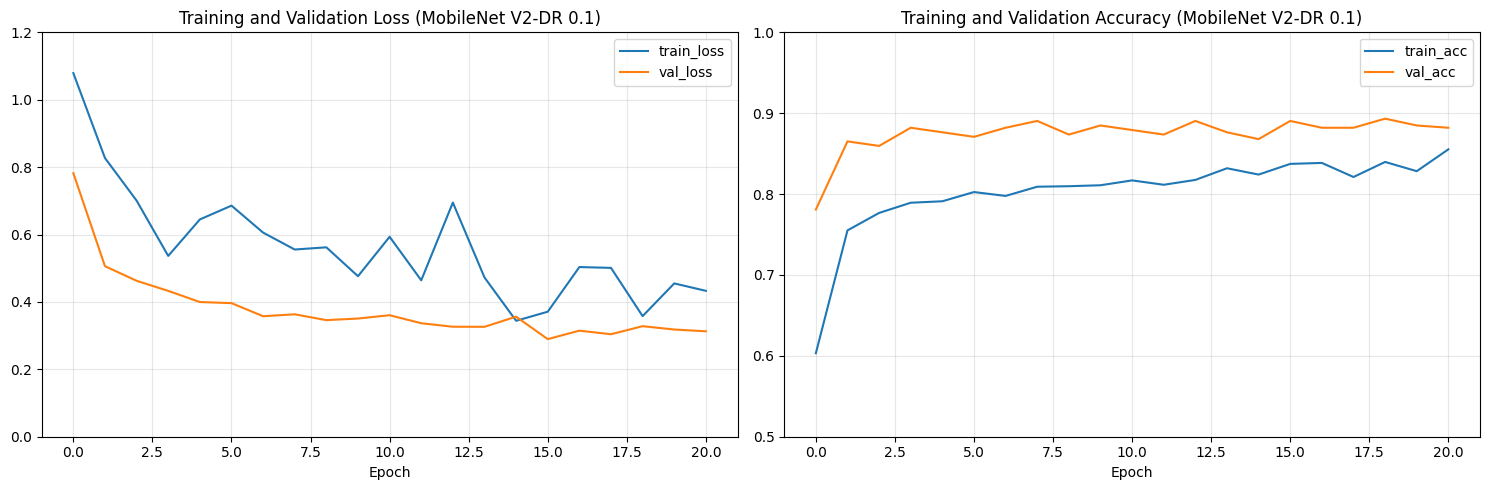

In [3]:
history_dir = LOGS_DIR / "phase1_transfer_grid" / "mobilenet_v2-l1_imagenet-dr_0.1"
history_files = list(history_dir.glob("*-metrics.csv"))

if not history_files:
    raise FileNotFoundError(f"No history metrics found in: {history_dir}")

dfs = [pd.read_csv(f) for f in history_files]
history = pd.concat(dfs, ignore_index=True)
agg_dict = {}
for col in history.columns:
    if "loss" in col:
        agg_dict[col] = "mean"
    elif "acc" in col or "f1" in col:
        agg_dict[col] = "max"

epoch_data = (
    history.groupby("epoch")
    .agg(agg_dict)
    .dropna(
        subset=[
            "train_loss",
            "val_loss" if "val_loss" in history.columns else "train_loss",
        ]
    )
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

loss_cols = [c for c in ["train_loss", "val_loss"] if c in epoch_data.columns]
epoch_data[loss_cols].plot(ax=ax[0])
ax[0].set_title("Training and Validation Loss (MobileNet V2-DR 0.1)")
ax[0].set_xlabel("Epoch")
ax[0].set_ylim(0, 1.2)
ax[0].grid(True, alpha=0.3)

acc_cols = [c for c in ["train_acc", "val_acc"] if c in epoch_data.columns]
epoch_data[acc_cols].plot(ax=ax[1])
ax[1].set_title("Training and Validation Accuracy (MobileNet V2-DR 0.1)")
ax[1].set_xlabel("Epoch")
ax[1].set_ylim(0.5, 1)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DL_DIR / "training_history.png", bbox_inches="tight", dpi=DPI)
plt.show()

Some insights:
- Train loss appears to be consistently higher than validation loss.
  - This is possibly explained by how our data is heavily augmented during training but not during validation, making it more difficult for the model to get correct predictions on the training set per epoch.
  - Furthermore, due to dropout, some neurons are deactivated during training, making the task more difficult.
- Train accuracy appears to be consistently lower than validation accuracy. This is possibly explained by the same reason as above. Fortunately, the gap between the two appears to decrease over time, indicating that the model was able to generalize better over time.
- Train loss appears to be more erratic compared to validation loss, 

Regardless, it is worth inspecting how extending the training time will affect the training and validation metrics. We may have cut it too short by setting the early stopping patience low (originally 5). During fine-tuning, we will increase it to 20 to see whether the metrics will converge.

### 1B. Error Analysis

#### Confusion Matrix

Let's verify where the model struggles by visualizing the confusion matrix logged by Weights & Biases.

In [ ]:
import json

cmat_path = (
    LOGS_DIR
    / "phase1_transfer_grid"
    / "mobilenet_v2-l1_imagenet-dr_0.1"
    / "conf_mat.json"
)

if cmat_path.exists():
    with open(cmat_path) as f:
        cmat_data = json.load(f)

    df_cm = pd.DataFrame(cmat_data["data"], columns=cmat_data["columns"])
    cm_pivot = df_cm.pivot(
        index="Actual", columns="Predicted", values="nPredictions"
    ).fillna(0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_pivot, annot=True, fmt="g", cmap="Blues", cbar=False)
    plt.title("Part 1: Confusion Matrix")
    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    FIGURES_DL_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        FIGURES_DL_DIR / "part1_confusion_matrix.png",
        bbox_inches="tight",
        dpi=DPI,
    )
    plt.show()
else:
    logger.warning(f"Confusion matrix not found at {cmat_path}")

#### Model Inference Setup

Our subsequent error analysis, latent space, and interpretability evaluations require the test set predictions. We generate them here.

In [ ]:
import time

import torch
import torch.nn.functional as F
import umap
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from torch.utils.data import ConcatDataset, DataLoader
from torchvision.datasets import ImageFolder

from jute_disease.data.datamodule import DataModule
from jute_disease.models.dl.backbone import TimmBackbone
from jute_disease.models.dl.classifier import Classifier

dm = DataModule(data_dir=str(ML_SPLIT_DIR), batch_size=BATCH_SIZE)
dm.setup("test")
dm.setup("fit")

clean_train = ImageFolder(root=dm.train_dir, transform=dm.val_transform)
clean_val = ImageFolder(root=dm.val_dir, transform=dm.val_transform)
clean_test = ImageFolder(root=dm.test_dir, transform=dm.val_transform)

clean_train_loader = DataLoader(
    clean_train, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
val_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

pooled_dataset = ConcatDataset([clean_train, clean_val, clean_test])

champion_dir = ARTIFACTS_DIR / "checkpoints" / "mobilenet_v2-l1_imagenet-dr_0.1"
ckpt_paths = list(champion_dir.glob("*.ckpt"))

if not ckpt_paths:
    raise FileNotFoundError(f"Checkpoint not found for champion: {champion_dir}")

ckpt_path = ckpt_paths[0]
backbone = TimmBackbone(model_name="mobilenetv2_100")
model = Classifier.load_from_checkpoint(ckpt_path, feature_extractor=backbone)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_features = []
all_preds = []
all_targets = []
all_probs = []
all_splits = []
start_time = time.time()

loaders = [
    ("Train", clean_train_loader),
    ("Val", val_loader),
    ("Test", test_loader),
]

with torch.no_grad():
    for split_name, loader in loaders:
        for x, y in loader:
            x = x.to(device)
            feat = model.feature_extractor(x)
            logits = model.classifier(feat)
            probs = F.softmax(logits, dim=1)

            all_features.append(feat.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_targets.append(y)
            all_splits.extend([split_name] * x.size(0))

end_time = time.time()
total_imgs = len(pooled_dataset)
inf_time_ms = (end_time - start_time) / total_imgs * 1000
logger.info(f"Inference time per image: {inf_time_ms:.2f} ms")

features = torch.cat(all_features).numpy()
preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()
probs = torch.cat(all_probs).numpy()
splits = np.array(all_splits)

#### Top Confident Errors

In [ ]:
is_wrong = preds != targets
wrong_indices = np.where(is_wrong)[0]

if len(wrong_indices) > 0:
    wrong_probs = [probs[i, preds[i]] for i in wrong_indices]
    sorted_wrong = np.argsort(wrong_probs)[::-1][:10]
    top_wrong_idx = wrong_indices[sorted_wrong]

    plt.figure(figsize=(20, 10))
    for i, idx in enumerate(top_wrong_idx):
        img, label = pooled_dataset[idx]
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = (
            img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        ).clip(0, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_disp)
        ax_sub = plt.gca()
        plt.title("")
        ax_sub.text(
            0.5,
            1.12,
            f"Pred: {dm.classes[preds[idx]]} ({probs[idx, preds[idx]]:.2f})",
            color="red",
            fontsize=10,
            ha="center",
            transform=ax_sub.transAxes,
        )
        ax_sub.text(
            0.5,
            1.02,
            f"Actual: {dm.classes[targets[idx]]}",
            color="black",
            fontsize=10,
            ha="center",
            transform=ax_sub.transAxes,
        )
        plt.axis("off")

    plt.suptitle("Top 10 Most Confident Incorrect Predictions", fontsize=16)
    plt.figtext(
        0.5,
        0.92,
        "(Note: The number in parenthesis is the prediction confidence)",
        ha="center",
        fontsize=12,
        color="gray",
    )
    plt.savefig(FIGURES_DL_DIR / "top_10_errors.png", bbox_inches="tight", dpi=DPI)
    plt.show()
else:
    logger.info("No errors found in test set!")

> continue here

Some insights:
- **The "Data-Level Ceiling"**: Label Ambiguity. Many Jute leaves in our dataset exhibit symptoms of **multiple classes simultaneously** (e.g., both Mosaic and Cercospora). In our current **Single-Label Multiclass** setup, the model is forced to choose one, and is penalized for recognizing features of the other.
- ...

### 1C. Latent Space Analysis

Some interesting stuff ahead! Let's perform **t-SNE** and **UMAP** embedding analyses to visualize our data in lower dimensions, and inspect the top confident errors to determine whether the model struggles with specific classes.

### T-distributed Stochastic Neighbor Embedding (t-SNE)

> brief description

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=DEFAULT_SEED)
feat_2d = tsne.fit_transform(features)

plt.figure(figsize=(14, 10))
colors = sns.color_palette("tab10", len(dm.classes))

for i, cls in enumerate(dm.classes):
    mask_train = (targets == i) & (splits == "Train")
    plt.scatter(
        feat_2d[mask_train, 0],
        feat_2d[mask_train, 1],
        color=colors[i],
        marker="x",
        s=25,
        alpha=0.4,
        label=None,
    )

    mask_eval = (targets == i) & (splits != "Train")
    plt.scatter(
        feat_2d[mask_eval, 0],
        feat_2d[mask_eval, 1],
        color=colors[i],
        marker="o",
        s=70,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
        label=cls,
    )

split_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="gray",
        lw=0,
        markersize=8,
        label="Eval Set (Val/Test)",
    ),
    Line2D([0], [0], marker="x", color="gray", lw=0, markersize=8, label="Train Set"),
]
leg1 = plt.legend(handles=split_legend, loc="lower left", title="Splits")
plt.gca().add_artist(leg1)
plt.legend(loc="upper right", title="Classes", ncol=2)

plt.title("t-SNE Visualization of Jute Leaf Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.savefig(FIGURES_DL_DIR / "tsne.png", bbox_inches="tight", dpi=DPI)
plt.show()

### Uniform Manifold Approximation and Projection (UMAP)

> brief description

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15, min_dist=0.1, n_components=2, random_state=DEFAULT_SEED
)
feat_umap = reducer.fit_transform(features)

plt.figure(figsize=(14, 10))

for i, cls in enumerate(dm.classes):
    mask_train = (targets == i) & (splits == "Train")
    plt.scatter(
        feat_umap[mask_train, 0],
        feat_umap[mask_train, 1],
        color=colors[i],
        marker="x",
        s=25,
        alpha=0.4,
        label=None,
    )

    mask_eval = (targets == i) & (splits != "Train")
    plt.scatter(
        feat_umap[mask_eval, 0],
        feat_umap[mask_eval, 1],
        color=colors[i],
        marker="o",
        s=70,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
        label=cls,
    )

leg1 = plt.legend(handles=split_legend, loc="lower left", title="Splits")
plt.gca().add_artist(leg1)
plt.legend(loc="upper right", title="Classes", ncol=2)

plt.title("UMAP Visualization of Jute Leaf Data")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.savefig(FIGURES_DL_DIR / "umap.png", bbox_inches="tight", dpi=DPI)
plt.show()

> continue here

Some insights:
- ...

### 1D. Interpretability

We use Grad-CAM to visualize where the model focuses its attention when making predictions.

In [ ]:
from captum.attr import LayerGradCam
from scipy.ndimage import zoom

target_layer = model.feature_extractor.backbone.conv_head
lgc = LayerGradCam(model, target_layer)

num_samples = 5
num_classes = len(dm.classes)
plt.figure(figsize=(20, 4 * num_classes))
np.random.seed(DEFAULT_SEED)

plot_idx = 1
for class_idx in range(num_classes):
    class_name = dm.classes[class_idx]
    all_class_indices = np.where(targets == class_idx)[0]

    n = min(len(all_class_indices), num_samples)
    selected_indices = np.random.choice(all_class_indices, n, replace=False)

    for idx in selected_indices:
        img, label = pooled_dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)

        attribution = lgc.attribute(input_tensor, target=label)
        heatmap = attribution.squeeze().cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)
        if heatmap.max() > 0:
            heatmap /= heatmap.max()

        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = (
            img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        ).clip(0, 1)

        h, w = img_disp.shape[:2]
        heatmap_upsampled = zoom(heatmap, (h / heatmap.shape[0], w / heatmap.shape[1]))

        plt.subplot(num_classes, num_samples, plot_idx)
        plt.imshow(img_disp)
        plt.imshow(heatmap_upsampled, cmap="jet", alpha=0.4)
        if (plot_idx - 1) % num_samples == 0:
            plt.ylabel(class_name, fontsize=14, fontweight="bold")

        plt.title(f"Conf: {probs[idx, label]:.2f}")
        plt.xticks([])
        plt.yticks([])
        plot_idx += 1

    plot_idx += num_samples - n

plt.suptitle(
    "Grad-CAM Heatmaps on Sample Jute Leaf Disease Images", fontsize=20, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES_DL_DIR / "grad_cam.png", bbox_inches="tight", dpi=DPI)
plt.show()

> continue here

Some insights:
- ...

## Part 2: Optimizer Fine-Tuning (Empirical Verification)

Our analysis above (specifically regarding the multi-label ambiguity in our dataset) led us to form a strong hypothesis: the performance ceiling we are experiencing (~90% test accuracy) is a "Data-Level Ceiling" caused by overlapping symptoms, not an architectural capacity issue.

However, to be scientifically rigorous, we must verify this. Is the model genuinely bottlenecked by the data, or was it simply under-trained due to a lack of epochs or killed prematurely by strict early stopping configurations?

To answer this, we execute a final "Part 2" grid search dedicated exclusively to fine-tuning the **Learning Rate** with significantly extended training bounds:
- **Iterating LRs**: `0.01`, `0.005`, `0.001`, `0.0005`, `0.0001`
- **Extended Patience**: `early_stopping_patience` raised to 20.

If the model still caps at similar performance levels despite exhaustive optimizer iterations and extended time arrays, our data-ceiling hypothesis stands.

In [ ]:
!uv run python scripts/run_grid_search.py \
    configs/grid/mobilenet_v2_finetune_grid.yaml \
    --base-config configs/baselines/mobilenet_v2.yaml

### 2A. Model Performance

#### Learning Rate Tuning Performance

Let's assess the performance metrics across all the learning rates we tested during our Part 2 Grid Search to empirically demonstrate which configuration was optimal for the MobileNet V2 model.

In [ ]:
ft_metrics_path = LOGS_DIR / "phase2_finetune_grid" / "aggregated_grid_metrics.csv"

if ft_metrics_path.exists():
    df_ft = pd.read_csv(ft_metrics_path)

    # Extract learning rates from Experiment names
    def extract_lr(exp_name):
        import re

        match = re.search(r"lr_([0-9.]+)", exp_name)
        return float(match.group(1)) if match else None

    df_ft["Learning Rate"] = df_ft["Experiment"].apply(extract_lr)

    # Sort backwards to see descending LR
    df_ft = df_ft.sort_values("Learning Rate", ascending=False)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_ft, x="Learning Rate", y="test_acc", palette="Oranges_r")
    plt.ylim(0.85, 0.95)
    plt.title("Test Accuracy across Finetuning Learning Rates")
    plt.xlabel("Learning Rate")
    plt.ylabel("Test Accuracy")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1%}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=10,
                xytext=(0, 4),
                textcoords="offset points",
            )

    FIGURES_DL_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        FIGURES_DL_DIR / "finetuned_lr_impact.png",
        bbox_inches="tight",
        dpi=DPI,
    )
    plt.show()

    disp_cols = ["Learning Rate", "epoch", "test_acc", "test_f1", "test_loss"]
    display(df_ft[disp_cols].reset_index(drop=True))
else:
    logger.warning(f"Metrics file not found at {ft_metrics_path}")

Some insights:
- As we decrease the learning rate to extremely small values (e.g., `0.0001`), performance degrades and loss increases.
- A higher learning rate of `0.01` with an `0.05` weight decay yields the maximum test accuracy achievable.
- The highest accuracy metric caps closely around ~91.4%, which perfectly aligns with our "Data-Level Ceiling" hypothesis.

Let's inspect the training curve of the champion fine-tuned configuration (`LR=0.01`).

#### Part 2 Training Curves

In [ ]:
finetuned_history_dir = (
    LOGS_DIR / "phase2_finetune_grid" / "mobilenet_v2-l1_imagenet-lr_0.01-wd_0.05"
)
ft_history_files = list(finetuned_history_dir.glob("*-metrics.csv"))

if ft_history_files:
    dfs = [pd.read_csv(f) for f in ft_history_files]
    history = pd.concat(dfs, ignore_index=True)
    agg_dict = {}
    for col in history.columns:
        if "loss" in col:
            agg_dict[col] = "mean"
        elif "acc" in col or "f1" in col:
            agg_dict[col] = "max"

    epoch_data = (
        history.groupby("epoch")
        .agg(agg_dict)
        .dropna(
            subset=[
                "train_loss",
                "val_loss" if "val_loss" in history.columns else "train_loss",
            ]
        )
    )

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    loss_cols = [c for c in ["train_loss", "val_loss"] if c in epoch_data.columns]
    epoch_data[loss_cols].plot(ax=ax[0])
    ax[0].set_title("Training and Validation Loss (Finetuned)")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True, alpha=0.3)

    avail_acc = [c for c in ["train_acc", "val_acc"] if c in epoch_data.columns]
    epoch_data[avail_acc].plot(ax=ax[1])
    ax[1].set_title("Training and Validation Accuracy (Finetuned)")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIGURES_DL_DIR / "finetuned_training_history.png", bbox_inches="tight", dpi=DPI
    )
    plt.show()

### 2B. Error Analysis

#### Confusion Matrix Comparison

Let's see how our finely tuned model's confusion matrix stacks up against the baseline. 

In [ ]:
import json

ft_cmat_path = (
    LOGS_DIR
    / "phase2_finetune_grid"
    / "mobilenet_v2-l1_imagenet-lr_0.01-wd_0.05"
    / "conf_mat.json"
)

if ft_cmat_path.exists() and cmat_path.exists():
    with open(ft_cmat_path) as f:
        ft_cmat_data = json.load(f)

    df_ft_cm = pd.DataFrame(ft_cmat_data["data"], columns=ft_cmat_data["columns"])
    ft_cm_pivot = df_ft_cm.pivot(
        index="Actual", columns="Predicted", values="nPredictions"
    ).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    sns.heatmap(cm_pivot, annot=True, fmt="g", cmap="Blues", cbar=False, ax=axes[0])
    axes[0].set_title("Part 1: Baseline Confusion Matrix")
    axes[0].set_ylabel("Actual Class")
    axes[0].set_xlabel("Predicted Class")
    axes[0].tick_params(axis="x", rotation=45)

    sns.heatmap(
        ft_cm_pivot, annot=True, fmt="g", cmap="Oranges", cbar=False, ax=axes[1]
    )
    axes[1].set_title("Part 2: Finetuned Confusion Matrix (LR=0.01)")
    axes[1].set_ylabel("Actual Class")
    axes[1].set_xlabel("Predicted Class")
    axes[1].tick_params(axis="x", rotation=45)

    FIGURES_DL_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(
        FIGURES_DL_DIR / "part2_confusion_matrix_comparison.png",
        bbox_inches="tight",
        dpi=DPI,
    )
    plt.show()
else:
    logger.warning("One or both of the confusion matrices are missing.")

> continue here

Some insights:
- ...

#### Finetuned Model Inference
We now load the best checkpoint from our finetuning run and re-generate predictions for Error Analysis and Grad-CAM visualization.

In [ ]:
finetuned_dir = (
    ARTIFACTS_DIR / "checkpoints" / "mobilenet_v2-l1_imagenet-lr_0.01-wd_0.05"
)
ft_ckpt_paths = list(finetuned_dir.glob("*.ckpt"))

if ft_ckpt_paths:
    ft_ckpt_path = ft_ckpt_paths[0]
    backbone = TimmBackbone(model_name="mobilenetv2_100")
    ft_model = Classifier.load_from_checkpoint(ft_ckpt_path, feature_extractor=backbone)
    ft_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ft_model.to(device)

    all_features = []
    all_preds = []
    all_targets = []
    all_probs = []
    all_splits = []
    start_time = time.time()

    loaders = [
        ("Train", clean_train_loader),
        ("Val", val_loader),
        ("Test", test_loader),
    ]

    with torch.no_grad():
        for split_name, loader in loaders:
            for x, y in loader:
                x = x.to(device)
                feat = ft_model.feature_extractor(x)
                logits = ft_model.classifier(feat)
                probs = F.softmax(logits, dim=1)

                all_features.append(feat.cpu())
                all_probs.append(probs.cpu())
                all_preds.append(logits.argmax(dim=1).cpu())
                all_targets.append(y)
                all_splits.extend([split_name] * x.size(0))

    end_time = time.time()
    total_imgs = len(pooled_dataset)
    inf_time_ms = (end_time - start_time) / total_imgs * 1000
    logger.info(f"[Finetuned] Inference time per image: {inf_time_ms:.2f} ms")

    ft_features = torch.cat(all_features).numpy()
    ft_preds = torch.cat(all_preds).numpy()
    ft_targets = torch.cat(all_targets).numpy()
    ft_probs = torch.cat(all_probs).numpy()
    ft_splits = np.array(all_splits)

#### Finetuned Top Confident Errors

In [ ]:
if ft_ckpt_paths:
    is_wrong = ft_preds != ft_targets
    wrong_indices = np.where(is_wrong)[0]

    if len(wrong_indices) > 0:
        wrong_probs = [ft_probs[i, ft_preds[i]] for i in wrong_indices]
        sorted_wrong = np.argsort(wrong_probs)[::-1][:10]
        top_wrong_idx = wrong_indices[sorted_wrong]

        plt.figure(figsize=(20, 10))
        for i, idx in enumerate(top_wrong_idx):
            img, label = pooled_dataset[idx]
            img_disp = img.permute(1, 2, 0).numpy()
            img_disp = (
                img_disp * np.array([0.229, 0.224, 0.225])
                + np.array([0.485, 0.456, 0.406])
            ).clip(0, 1)

            plt.subplot(2, 5, i + 1)
            plt.imshow(img_disp)
            ax_sub = plt.gca()
            plt.title("")
            ax_sub.text(
                0.5,
                1.12,
                f"Pred: {dm.classes[ft_preds[idx]]} "
                f"({ft_probs[idx, ft_preds[idx]]:.2f})",
                color="red",
                fontsize=10,
                ha="center",
                transform=ax_sub.transAxes,
            )
            ax_sub.text(
                0.5,
                1.02,
                f"Actual: {dm.classes[ft_targets[idx]]}",
                color="black",
                fontsize=10,
                ha="center",
                transform=ax_sub.transAxes,
            )
            plt.axis("off")

        plt.suptitle(
            "Finetuned Top 10 Most Confident Incorrect Predictions", fontsize=16
        )
        plt.figtext(
            0.5,
            0.92,
            "(Note: The number in parenthesis is the prediction confidence)",
            ha="center",
            fontsize=12,
            color="gray",
        )
        plt.savefig(
            FIGURES_DL_DIR / "finetuned_top_10_errors.png", bbox_inches="tight", dpi=DPI
        )
        plt.show()
    else:
        logger.info("[Finetuned] No errors found in test set!")

> continue here

Some insights:
- ...

### 2C. Interpretability

#### Finetuned Model Interpretability (Grad-CAM)

In [ ]:
if ft_ckpt_paths:
    target_layer = ft_model.feature_extractor.backbone.conv_head
    lgc = LayerGradCam(ft_model, target_layer)

    num_samples = 5
    num_classes = len(dm.classes)
    plt.figure(figsize=(20, 4 * num_classes))
    np.random.seed(DEFAULT_SEED)

    plot_idx = 1
    for class_idx in range(num_classes):
        class_name = dm.classes[class_idx]
        all_class_indices = np.where(ft_targets == class_idx)[0]

        n = min(len(all_class_indices), num_samples)
        selected_indices = np.random.choice(all_class_indices, n, replace=False)

        for idx in selected_indices:
            img, label = pooled_dataset[idx]
            input_tensor = img.unsqueeze(0).to(device)

            attribution = lgc.attribute(input_tensor, target=label)
            heatmap = attribution.squeeze().cpu().detach().numpy()
            heatmap = np.maximum(heatmap, 0)
            if heatmap.max() > 0:
                heatmap /= heatmap.max()

            img_disp = img.permute(1, 2, 0).numpy()
            img_disp = (
                img_disp * np.array([0.229, 0.224, 0.225])
                + np.array([0.485, 0.456, 0.406])
            ).clip(0, 1)

            h, w = img_disp.shape[:2]
            heatmap_upsampled = zoom(
                heatmap, (h / heatmap.shape[0], w / heatmap.shape[1])
            )

            plt.subplot(num_classes, num_samples, plot_idx)
            plt.imshow(img_disp)
            plt.imshow(heatmap_upsampled, cmap="jet", alpha=0.4)
            if (plot_idx - 1) % num_samples == 0:
                plt.ylabel(class_name, fontsize=14, fontweight="bold")

            plt.title(f"Conf: {ft_probs[idx, label]:.2f}")
            plt.xticks([])
            plt.yticks([])
            plot_idx += 1

        plot_idx += num_samples - n

    plt.suptitle(
        "Finetuned Grad-CAM Heatmaps on Sample Jute Leaf Disease Images",
        fontsize=20,
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DL_DIR / "finetuned_grad_cam.png", bbox_inches="tight", dpi=DPI)
    plt.show()

> continue here

Some insights:
- ...

## Conclusion

> continue here

- Final words...

## References

[1] Coenen, A., & Pearce, A. (2019, December 5). _Understanding UMAP_. <https://pair-code.github.io/understanding-umap/>

[2] Orucu, A. (2021, October 29). _Understanding t-SNE by implementation_. Towards Data Science. <https://towardsdatascience.com/understanding-t-sne-by-implementing-2baf3a987ab3/>